<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/SVM_Kernels_Exercises_ANSWERS_De_los_Reyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines and Kernels

## Introduction

We will be using the wine quality data set for these exercises. This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data.csv`.

In [ ]:
'''
from __future__ import print_function
import os
data_path = ['..', '..', 'data']
'''

"\nfrom __future__ import print_function\nimport os\ndata_path = ['..', '..', 'data']\n"

## Question 1

* Import the data.
* Create the target variable `y` as a 1/0 column where 1 means red.
* Create a `pairplot` for the dataset.
* Create a bar plot showing the correlations between each column and `y`
* Pick the most 2 correlated fields (using the absolute value of correlations) and create `X`
* Use MinMaxScaler to scale `X`. Note that this will output a np.array. Make it a DataFrame again and rename the columns appropriately.

In [ ]:
import pandas as pd
import numpy as np

#filepath = os.sep.join(data_path + ['Wine_Quality_Data.csv'])
datapath = '/content/Wine_Quality_Data.csv'
data = pd.read_csv(datapath)

In [ ]:
data

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [ ]:
data['color'].unique()

array(['red', 'white'], dtype=object)

In [ ]:
y = (data['color'] == 'red').astype(int)
fields = list(data.columns[:-1])  # everything except "color"
correlations = data[fields].corrwith(y)
correlations.sort_values(inplace=True)
correlations

,0
total_sulfur_dioxide,-0.700357
free_sulfur_dioxide,-0.471644
residual_sugar,-0.348821
citric_acid,-0.187397
quality,-0.119323
alcohol,-0.032970
pH,0.329129
density,0.390645
fixed_acidity,0.486740
sulphates,0.487218


The total_sulfur_dioxide has the strong negative correlation among the features having a -0.70 and volatile_acidity has a strong positve correlation with 0.65 using pearson correlation thus, we can conclude that the color of the wine is may be affected by the total sulfur dioxide and the volatile acidity on its solution in making wine. This suggest that  red wines tend to have lower level of sulfur dioxide and high volatile acidity compare to the white wines.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

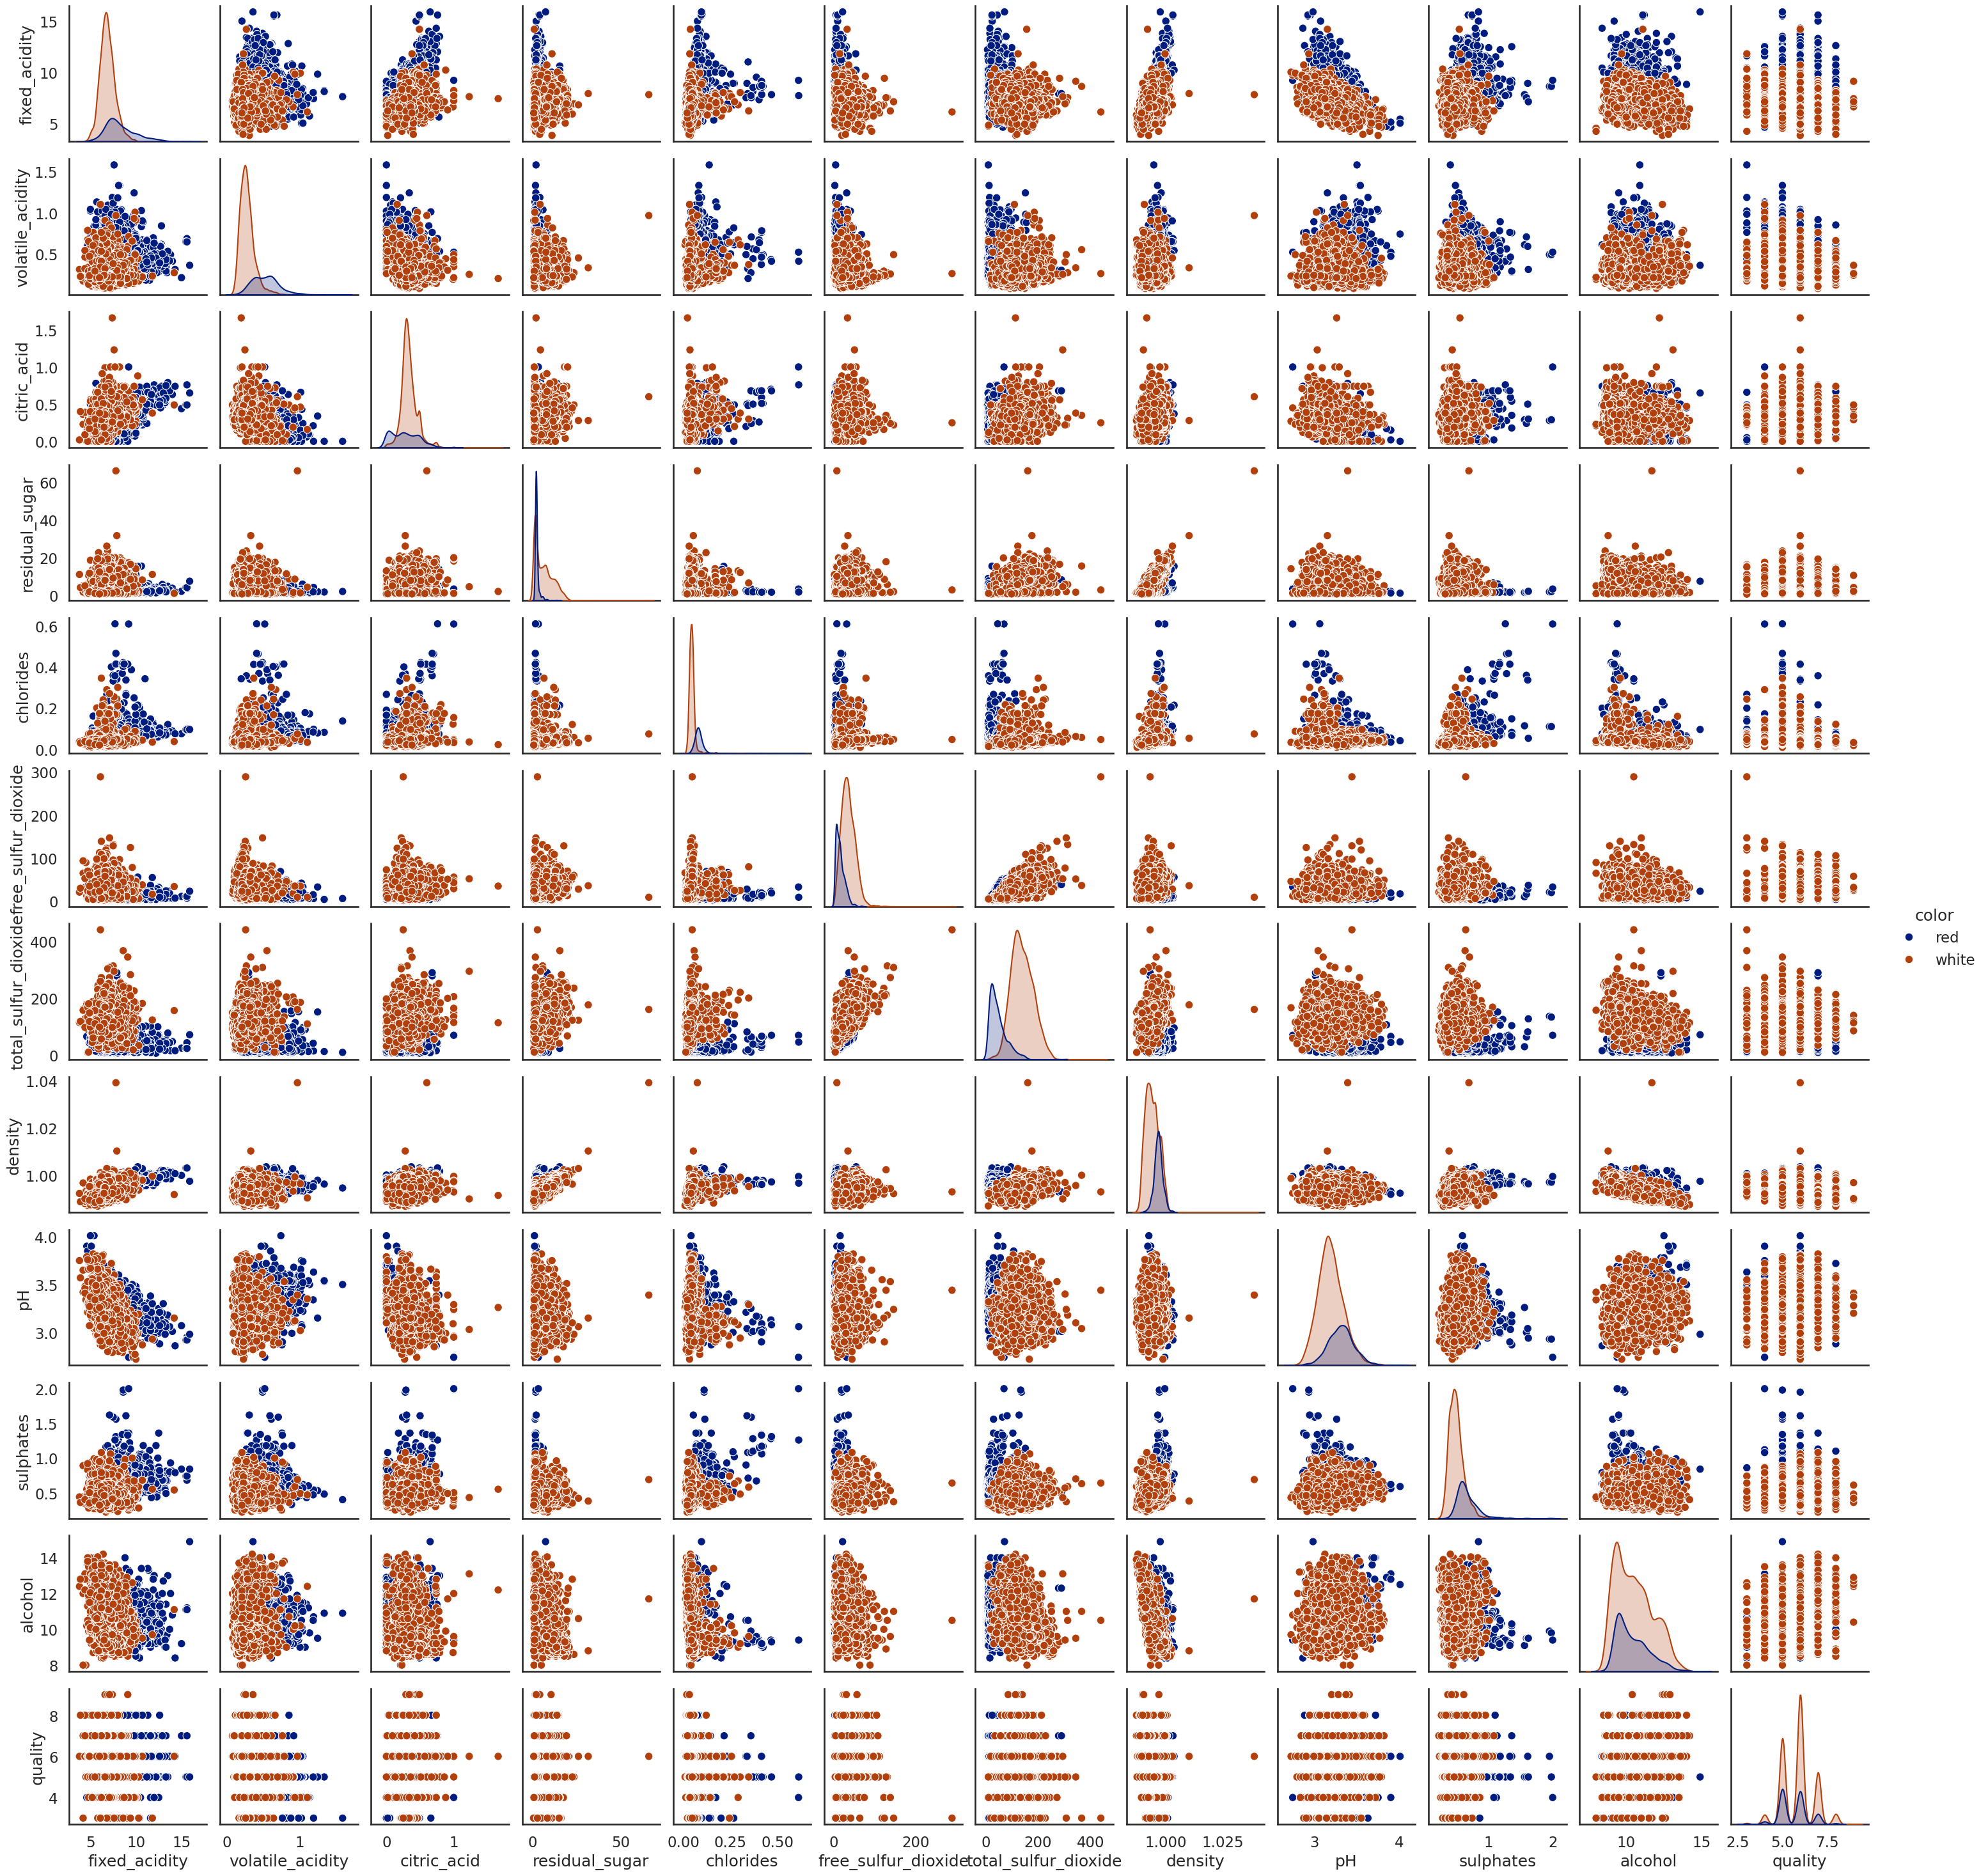

In [ ]:
sns.pairplot(data, hue='color')

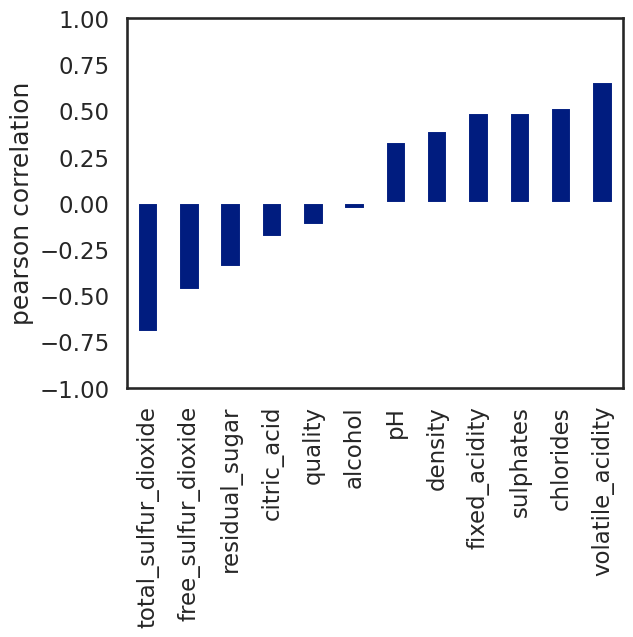

In [ ]:
ax = correlations.plot(kind='bar')
ax.set(ylim=[-1, 1], ylabel='pearson correlation');

In [ ]:
from sklearn.preprocessing import MinMaxScaler

fields = correlations.map(abs).sort_values().iloc[-2:].index
print(fields)
X = data[fields]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=['%s_scaled' % fld for fld in fields])
print(X.columns)

Index(['volatile_acidity', 'total_sulfur_dioxide'], dtype='object')
Index(['volatile_acidity_scaled', 'total_sulfur_dioxide_scaled'], dtype='object')


## Question 2

The goal for this question is to look at the decision boundary of a LinearSVC classifier on this dataset. Check out [this example](http://scikit-learn.org/stable/auto_examples/svm/plot_iris.html#sphx-glr-auto-examples-svm-plot-iris-py) in sklearn's documentation.

* Fit a Linear Support Vector Machine Classifier to `X`, `y`.
* Pick 300 samples from `X`. Get the corresponding `y` value. Store them in variables `X_color` and `y_color`. This is because original dataset is too large and it produces a crowded plot.
* Modify `y_color` so that it has the value "red" instead of 1 and 'yellow' instead of 0.
* Scatter plot X_color's columns. Use the keyword argument "color=y_color" to color code samples.
* Use the code snippet below to plot the decision surface in a color coded way.

```python
x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
y_grid_predictions = *[YOUR MODEL]*.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
```

Feel free to experiment with different parameter choices for LinearSVC and see the decision boundary.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


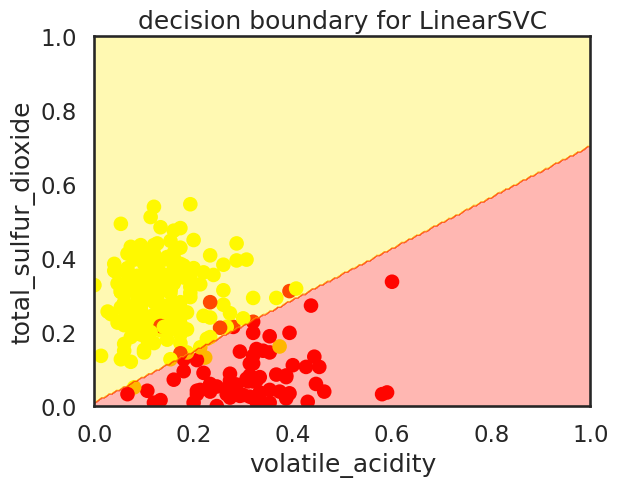

In [ ]:
from sklearn.svm import LinearSVC

LSVC = LinearSVC()
LSVC.fit(X, y)

X_color = X.sample(300, random_state=45)
y_color = y.loc[X_color.index]
y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
ax = plt.axes()
ax.scatter(
    X_color.iloc[:, 0], X_color.iloc[:, 1],
    color=y_color, alpha=1)
# -----------
x_axis, y_axis = np.arange(0, 1.005, .005), np.arange(0, 1.005, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
y_grid_predictions = LSVC.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
# -----------
ax.set(
    xlabel=fields[0],
    ylabel=fields[1],
    xlim=[0, 1],
    ylim=[0, 1],
    title='decision boundary for LinearSVC');

## Question 3

Let's now fit a Gaussian kernel SVC and see how the decision boundary changes.

* Consolidate the code snippets in Question 2 into one function which takes in an estimator, `X` and `y`, and produces the final plot with decision boundary. The steps are:
    <ol>
     <li> fit model
     <li> get sample 300 records from X and the corresponding y's
     <li> create grid, predict, plot using ax.contourf
     <li> add on the scatter plot
    </ol>
* After copying and pasting code, make sure the finished function uses your input `estimator` and not the LinearSVC model you built.
* For the following values of `gamma`, create a Gaussian Kernel SVC and plot the decision boundary.  
`gammas = [.5, 1, 2, 10]`
* Holding `gamma` constant, for various values of `C`, plot the decision boundary. You may try  
`Cs = [.1, 1, 10]`

In [ ]:
def plot_decision_boundary(estimator, X, y):
    estimator.fit(X, y)
    X_color = X.sample(300)
    y_color = y.loc[X_color.index]
    y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')
    x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
    xx, yy = np.meshgrid(x_axis, y_axis)
    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()
    X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
    y_grid_predictions = estimator.predict(X_grid)
    y_grid_predictions = y_grid_predictions.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
    ax.scatter(X_color.iloc[:, 0], X_color.iloc[:, 1], color=y_color, alpha=1)
    ax.set(
        xlabel=fields[0],
        ylabel=fields[1],
        title=str(estimator))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


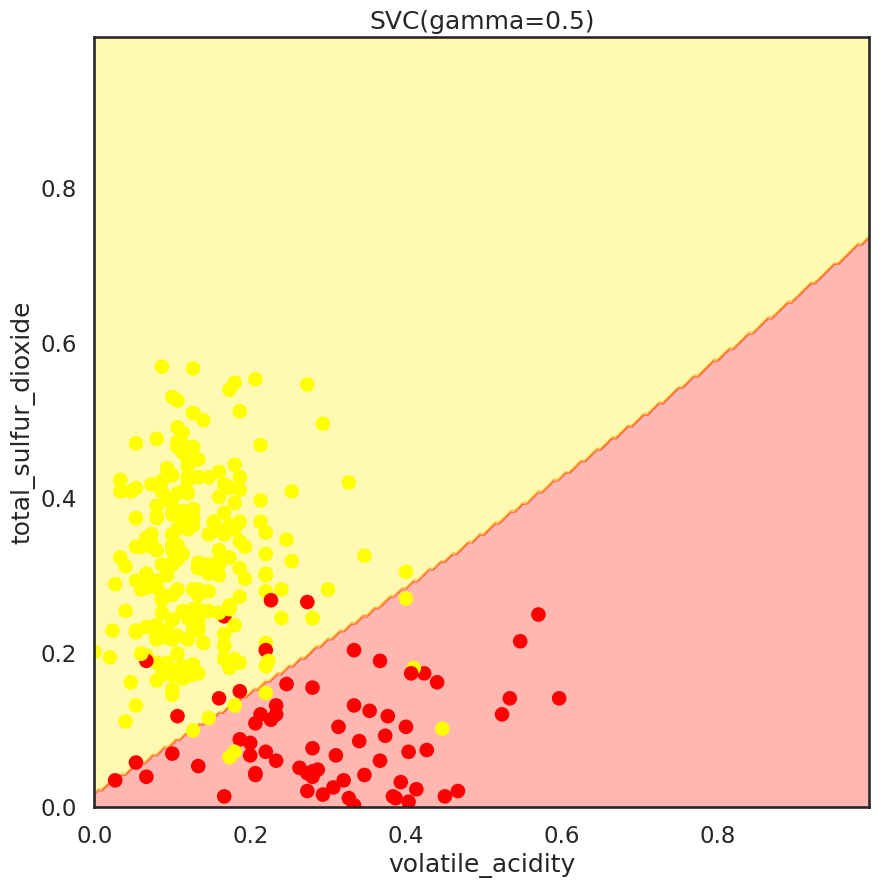

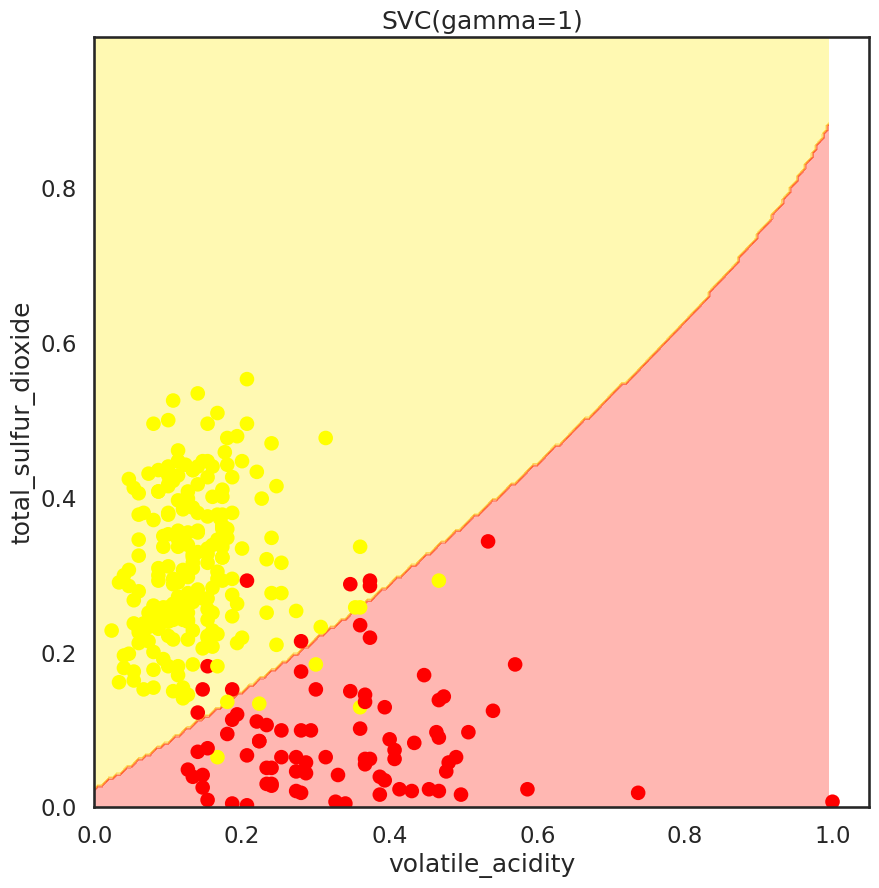

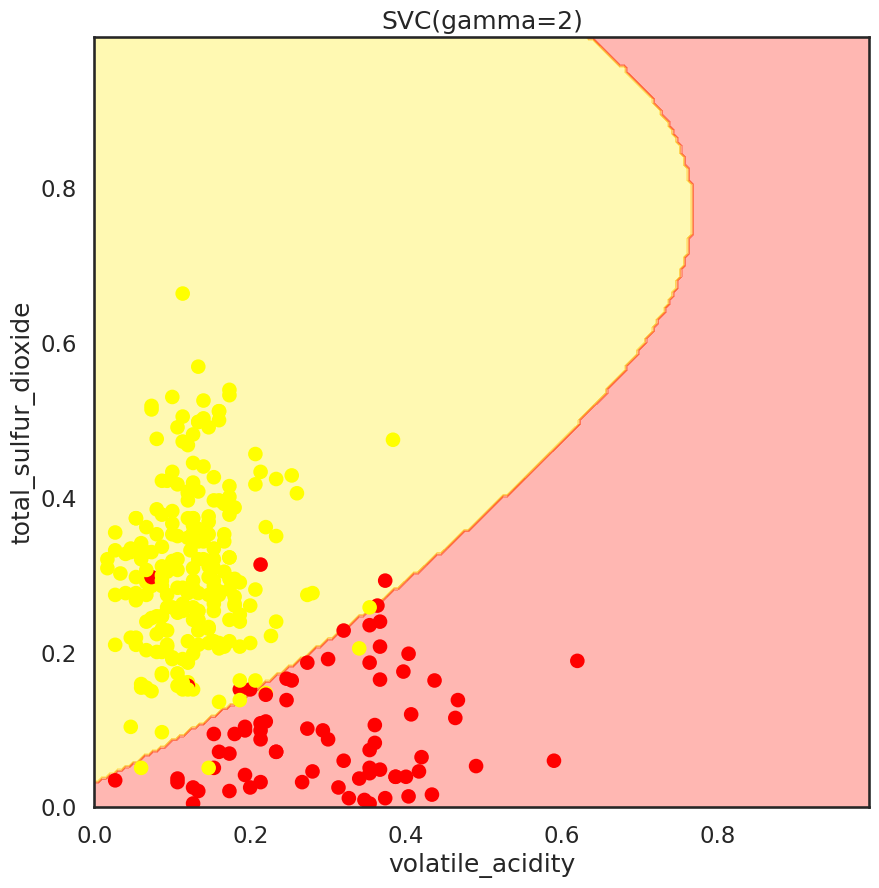

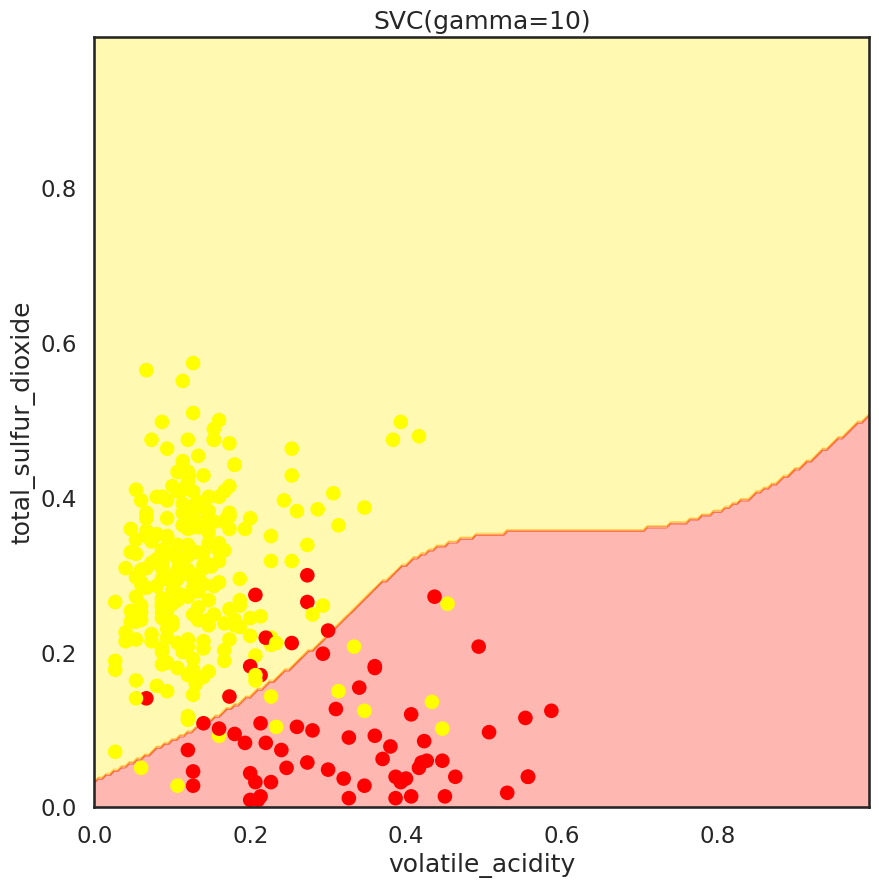

In [ ]:
from sklearn.svm import SVC

gammas = [.5, 1, 2, 10]
for gamma in gammas:
    SVC_Gaussian = SVC(kernel='rbf', gamma=gamma)
    plot_decision_boundary(SVC_Gaussian, X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


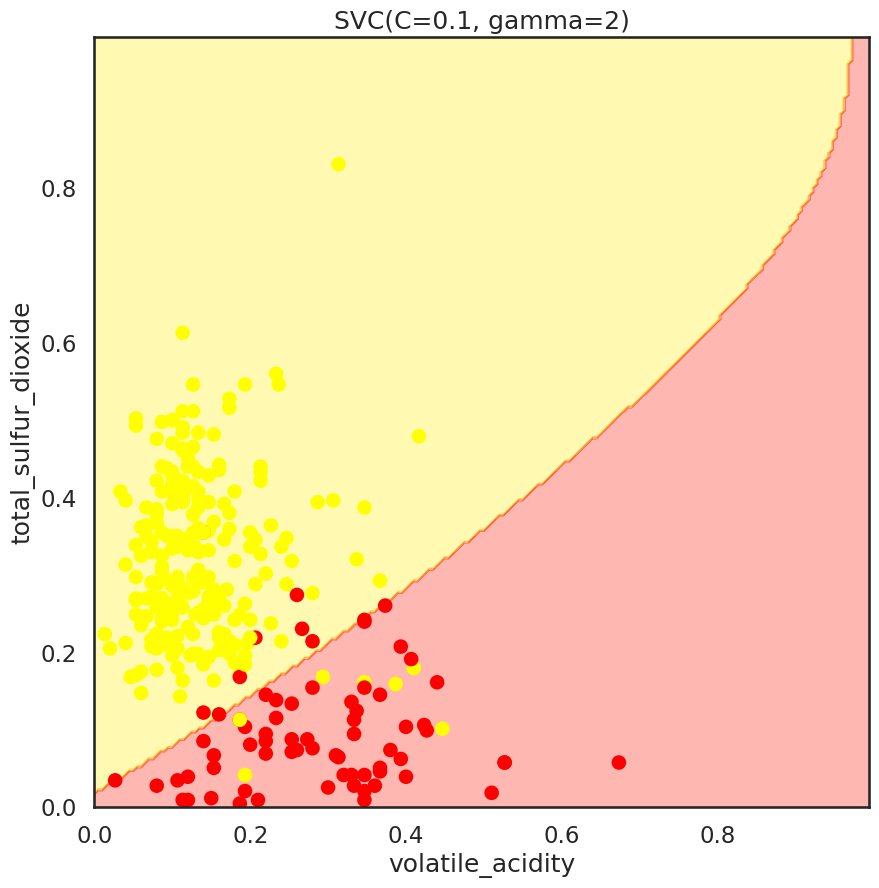

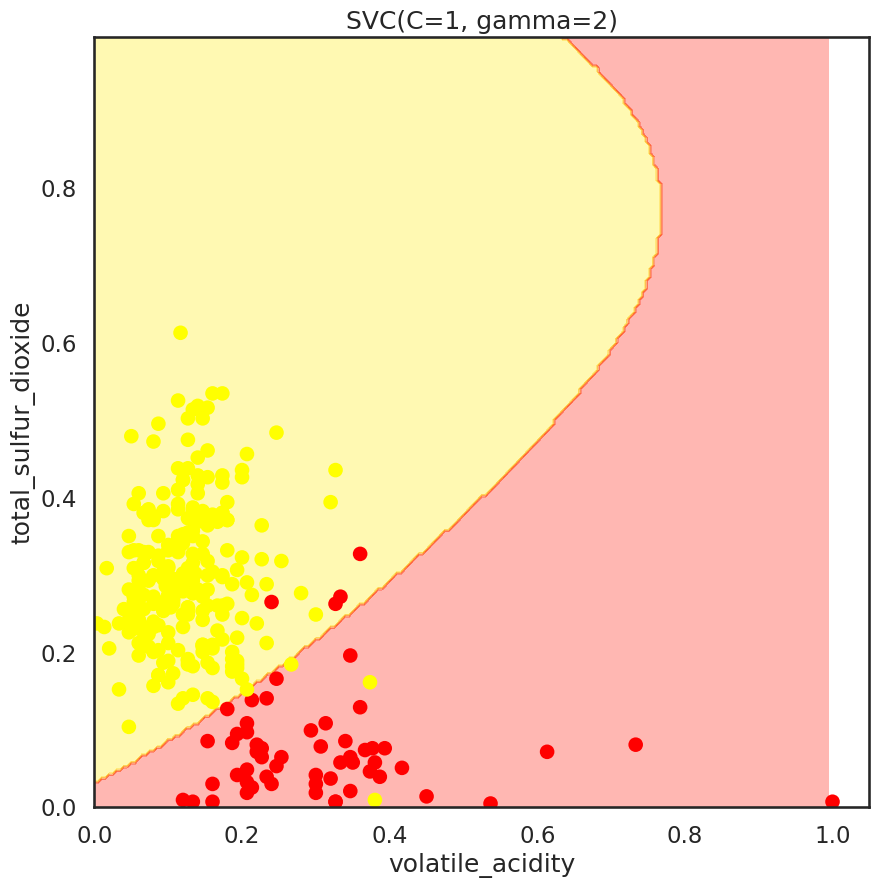

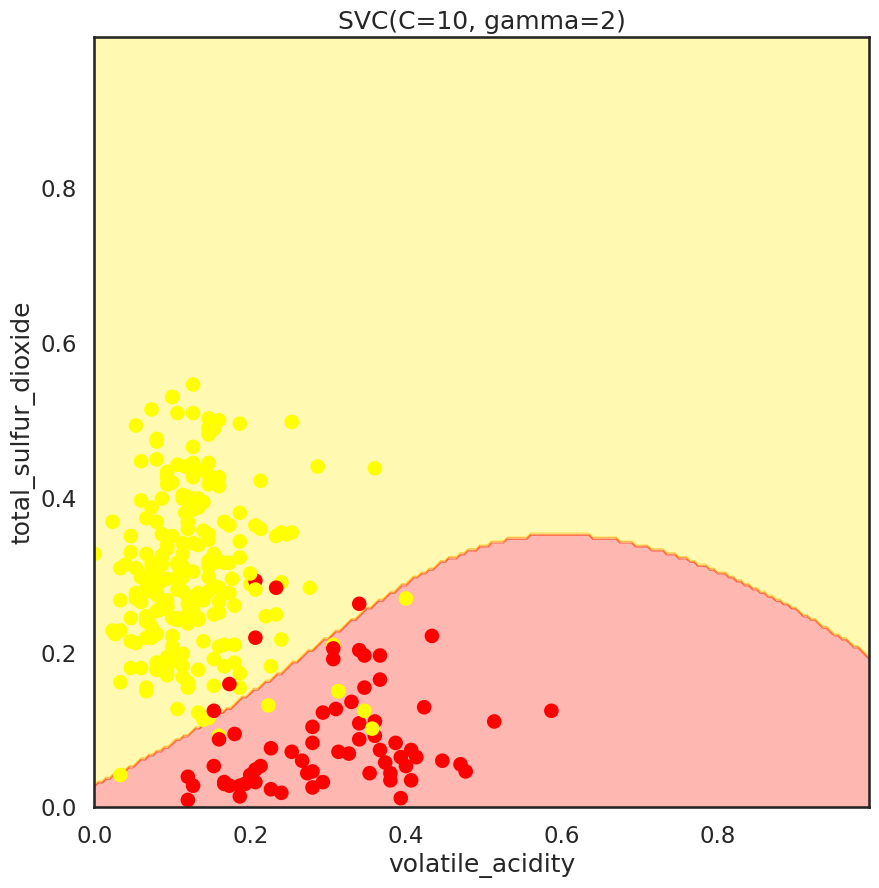

In [ ]:
Cs = [.1, 1, 10]
for C in Cs:
    SVC_Gaussian = SVC(kernel='rbf', gamma=2, C=C)
    plot_decision_boundary(SVC_Gaussian, X, y)

## Question 4

In this question, we will compare the fitting times between SVC vs Nystroem with rbf kernel.  
<br><br>
Jupyter Notebooks provide a useful magic function **`%timeit`** which executes a line and prints out the time it took to fit. If you type **`%%timeit`** in the beginning of the cell, then it will run the whole cell and output the running time.

* Re-load the wine quality data if you made changes to the original.
* Create `y` from data.color, and `X` from the rest of the columns.
* Use `%%timeit` to get the time for fitting an SVC with rbf kernel.
* Use `%%timeit` to get the time for the following: fit_transform the data with Nystroem and then fit a SGDClassifier.

Nystroem+SGD will take much shorter to fit. This difference will be more pronounced if the dataset was bigger.

* Make 5 copies of X and concatenate them
* Make 5 copies of y and concatenate them
* Compare the time it takes to fit the both methods above

In [ ]:
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

y = data.color == 'red'
X = data[data.columns[:-1]]

kwargs = {'kernel': 'rbf'}
svc = SVC(**kwargs)
nystroem = Nystroem(**kwargs)
sgd = SGDClassifier()

In [ ]:
%%timeit
svc.fit(X, y)

385 ms ± 6.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
X_transformed = nystroem.fit_transform(X)
sgd.fit(X_transformed, y)

The slowest run took 5.03 times longer than the fastest. This could mean that an intermediate result is being cached.
366 ms ± 226 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
X2 = pd.concat([X]*5)
y2 = pd.concat([y]*5)

print(X2.shape)
print(y2.shape)

(32485, 12)
(32485,)


In [ ]:
%timeit svc.fit(X2, y2)

11.1 s ± 1.31 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
X2_transformed = nystroem.fit_transform(X2)
sgd.fit(X2_transformed, y2)

543 ms ± 45.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Model Evaluation

Include Classification Report and Confusion Matrix

Evaluate the performance of using GridSearch versus Random Search in terms of accuracy both in testing training

Evaluate the confusion matrix, classification report and AUC ROC for Grid Search and Random Search for testing and training



In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.svm import SVC

In [ ]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((5197, 12), (1300, 12))

In [ ]:
y_train.shape, y_test.shape

((5197,), (1300,))

In [ ]:
#Setting up the SVM Classifier
svc = SVC(probability= True)

In [ ]:
#Setting up GridSearch parameters for SVM
param_grid = {
    'C': [0.1,1,10],
    'gamma': [0.5,1,2,10],
    'kernel': ['rbf','linear']
}

#Setting up RandomSearch parameters for SVM
param_dist = {
    'C': [0.1,1,10],
    'gamma': [0.5,1,2,10],
    'kernel': ['rbf','linear']
}



In [ ]:
# Perform GridSearch CV
grid_search = GridSearchCV(svc, param_grid, refit=True, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   6.7s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   5.3s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   6.6s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   5.3s
[CV] END .......................C=0.1, gamma=0.5, kernel=rbf; total time=   5.8s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   2.5s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   1.8s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   1.6s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   1.5s
[CV] END ....................C=0.1, gamma=0.5, kernel=linear; total time=   1.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   6.4s
[CV] END .........................C=0.1, gamma=

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.5, 1, 2, 10],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

In [ ]:
grid_search.best_params_

{'C': 10, 'gamma': 0.5, 'kernel': 'linear'}

In [ ]:
grid_search.best_estimator_

SVC(C=10, gamma=0.5, kernel='linear', probability=True)

In [ ]:
# Perform RandomSeach CV
random_search = RandomizedSearchCV(svc, param_distributions= param_dist, refit=True, verbose=2)
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   1.7s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   2.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   2.5s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   1.5s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   1.5s
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   4.2s
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   4.9s
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   4.5s
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   4.4s
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   4.1s
[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   6.1s
[CV] END ..........................C=10, gamma=1

RandomizedSearchCV(estimator=SVC(probability=True),
                   param_distributions={'C': [0.1, 1, 10],
                                        'gamma': [0.5, 1, 2, 10],
                                        'kernel': ['rbf', 'linear']},
                   verbose=2)

In [ ]:
random_search.best_params_

{'kernel': 'linear', 'gamma': 0.5, 'C': 10}

In [ ]:
random_search.best_estimator_

SVC(C=10, gamma=0.5, kernel='linear', probability=True)

In [ ]:
# Evaluate performance
def evaluate_model(search, X_train, X_test, y_train, y_test, name):
    print(f"Results for {name} Search")
    # Training set performance
    y_train_pred = search.predict(X_train)
    print(f"Training Accuracy: {search.score(X_train, y_train):.4f}")
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Testing set performance
    y_test_pred = search.predict(X_test)
    print(f"Testing Accuracy: {search.score(X_test, y_test):.4f}")
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Confusion matrix for test set
    print(f"Confusion Matrix (Test Set) for {name}:")
    print(confusion_matrix(y_test, y_test_pred))

    # AUC-ROC score and curve
    if len(np.unique(y_test)) == 2:
        auc_score = roc_auc_score(y_test, search.predict_proba(X_test)[:, 1])
        print(f"AUC-ROC (Test Set) for {name}: {auc_score:.4f}")

        fpr, tpr, _ = roc_curve(y_test, search.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f'{name} Search (AUC = {auc_score:.4f})')
    else:
        print(f"{name} AUC-ROC not available for multi-class classification")

Results for Grid Search
Training Accuracy: 0.9898
Training Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3939
        True       0.98      0.97      0.98      1258

    accuracy                           0.99      5197
   macro avg       0.99      0.98      0.99      5197
weighted avg       0.99      0.99      0.99      5197

Testing Accuracy: 0.9854
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       959
        True       0.98      0.96      0.97       341

    accuracy                           0.99      1300
   macro avg       0.98      0.98      0.98      1300
weighted avg       0.99      0.99      0.99      1300

Confusion Matrix (Test Set) for Grid:
[[952   7]
 [ 12 329]]
AUC-ROC (Test Set) for Grid: 0.9899


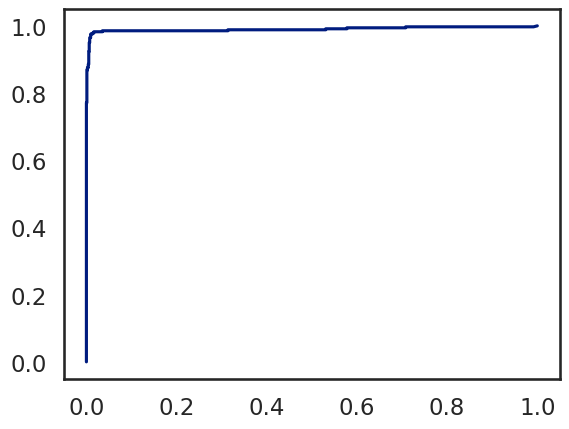

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, 'Grid')

Results for Random Search
Training Accuracy: 0.9898
Training Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3939
        True       0.98      0.97      0.98      1258

    accuracy                           0.99      5197
   macro avg       0.99      0.98      0.99      5197
weighted avg       0.99      0.99      0.99      5197

Testing Accuracy: 0.9854
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       959
        True       0.98      0.96      0.97       341

    accuracy                           0.99      1300
   macro avg       0.98      0.98      0.98      1300
weighted avg       0.99      0.99      0.99      1300

Confusion Matrix (Test Set) for Random:
[[952   7]
 [ 12 329]]
AUC-ROC (Test Set) for Random: 0.9899


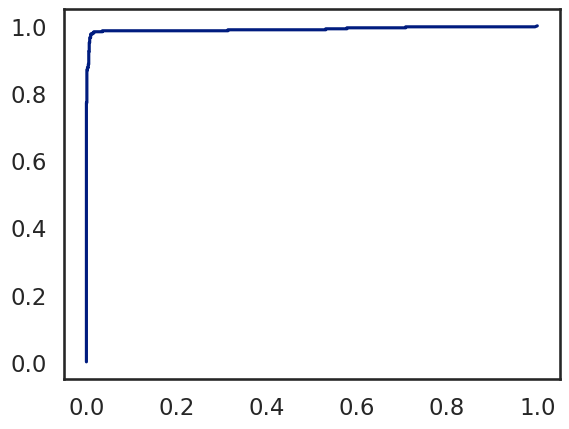

In [ ]:
evaluate_model(random_search, X_train, X_test, y_train, y_test, "Random")

Both Evaluation got an accuracy score of  98.98% in training and 98.54% in testing data.This suggest that our model is not overfitting and predict well. In confusion matrix we see that the model misses some positive cases but still perform really well. The AUC-ROC score of both model are 98.99% which suggest that our model has a good indicator to identify two classes of wine.